###  Library Imports
Import essential libraries for numerical computation (`numpy`), data manipulation (`pandas`), visualization (`matplotlib`, `seaborn`), and deep learning (`tensorflow`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import random
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, cohen_kappa_score, matthews_corrcoef,
    top_k_accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score, roc_curve, auc, classification_report
)
from sklearn.preprocessing import LabelBinarizer

###  Reproducibility Setup
Set seeds for Python, NumPy, and TensorFlow to ensure that the results are reproducible across different runs. We also enable deterministic operations in TensorFlow.

In [2]:
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Force TensorFlow to use deterministic operations (forces single-thread execution where needed)
tf.config.experimental.enable_op_determinism()

###  Data Acquisition
Fetch the MNIST dataset (70,000 images of handwritten digits) from OpenML using `fetch_openml`.

In [3]:
mnist = fetch_openml('mnist_784', as_frame = False)

###  Feature and Target Assignment
Assign the raw pixel data to `X` and the corresponding digit labels to `y`.

In [4]:
X, y = mnist.data,mnist.target

###  Data Normalization and Reshaping
Reshape the flat 784-pixel arrays into 28x28x1 images suitable for a Convolutional Neural Network (CNN) and normalize pixel values to the range [0, 1].

In [5]:
X = X.reshape(-1,28,28,1).astype(np.float32)/255.0
y = y.astype(np.int32)

###  Train-Test Split
Partition the dataset into a training set (80%) and a testing set (20%) to evaluate model performance on unseen data.

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

###  Verifying Training Dimensions
Check the shape of the training features and target to confirm the number of samples.

In [7]:
print(f'Shape of training set data: {X_train.shape}')
print(f'Shape of training set target : {y_train.shape}')

Shape of training set data: (56000, 28, 28, 1)
Shape of training set target : (56000,)


###  Verifying Test Dimensions
Check the shape of the test features and target to confirm the number of samples.

In [8]:
print(f'Shape of test set data: {X_test.shape}')
print(f'Shape of test set target : {y_test.shape}')

Shape of test set data: (14000, 28, 28, 1)
Shape of test set target : (14000,)


### Data Visualization
Visualize a single sample from the training set to verify data loading and normalization.

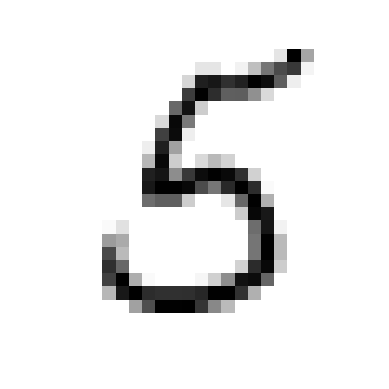

5


In [9]:
some_digit = X_train[0]
plt.imshow(some_digit,cmap = 'binary')
plt.axis('off')
plt.show()
print(y_train[0])

### Training Sample Grid
Display a 10x10 grid of the first 100 images in the training set to observe the variety of handwriting styles.

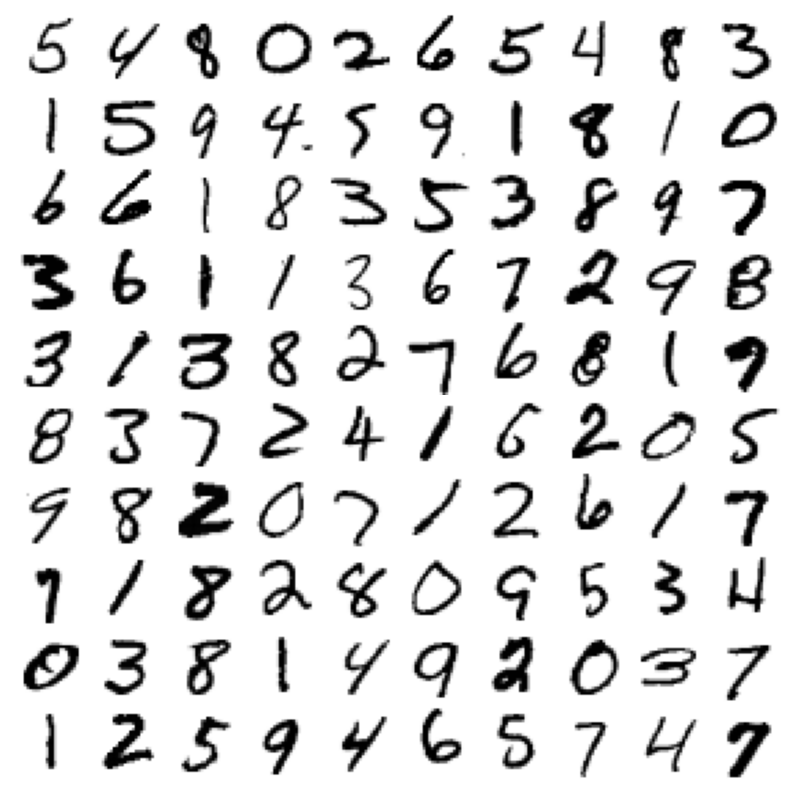

In [10]:
plt.figure(figsize = (10,10))
for i in range(100):
  plt.subplot(10,10,i+1)
  image = X_train[i]
  plt.imshow(image,cmap = 'binary')
  plt.axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

### CNN Model Architecture
Define a Sequential CNN with multiple Convolutional layers, Batch Normalization, MaxPooling, and Dropout for regularization.

In [11]:
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import BatchNormalization
model = tf.keras.Sequential([
    Input(shape = (28,28,1)),
    BatchNormalization(),
    tf.keras.layers.Conv2D(filters = 256,kernel_size = 7,activation = 'relu',kernel_initializer = 'he_normal',padding = 'same'),
    tf.keras.layers.MaxPool2D(pool_size = (2,2)),
    BatchNormalization(),
    tf.keras.layers.Conv2D(filters = 128,kernel_size = 5,activation = 'relu',kernel_initializer = 'he_normal',padding = 'same'),
    tf.keras.layers.Conv2D(filters = 128,kernel_size = 5,activation = 'relu',kernel_initializer = 'he_normal',padding = 'same'),
    tf.keras.layers.MaxPool2D(pool_size = (2,2)),
    BatchNormalization(),
    tf.keras.layers.Conv2D(filters = 256,kernel_size = 3,activation = 'relu',kernel_initializer = 'he_normal',padding = 'same'),
    tf.keras.layers.Conv2D(filters = 256,kernel_size = 3,activation = 'relu',kernel_initializer = 'he_normal',padding = 'same'),
    tf.keras.layers.MaxPool2D(pool_size = (2,2)),
    tf.keras.layers.Flatten(),
    BatchNormalization(),
    tf.keras.layers.Dense(units = 128,activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.Dropout(0.5),
    BatchNormalization(),
    tf.keras.layers.Dense(units = 64,activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.Dropout(0.4),
    BatchNormalization(),
    tf.keras.layers.Dense(units = 32,activation = 'relu',kernel_initializer = 'he_normal'),
    BatchNormalization(),
    tf.keras.layers.Dense(units = 16,activation = 'relu',kernel_initializer = 'he_normal'),
    BatchNormalization(),
    tf.keras.layers.Dense(units = 10,activation = 'softmax')
])

### Model Summary
Generate a summary of the model parameters and layer output shapes.

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 28, 28, 1)      │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 256)    │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2304)           │         9,216 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,444,894 (9.33 MB)

 Trainable params: 2,439,036 (9.30 MB)

 Non-trainable params: 5,858 (22.88 KB)

### Visualizing Model Graph
Generate a visual diagram of the model architecture showing the connectivity between layers, input/output shapes, and layer names.

In [13]:
tf.keras.utils.plot_model(
    model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True
);

### Model Compilation
Configure the model with the Adam optimizer, sparse categorical crossentropy loss, and accuracy metrics.

In [14]:
model.compile(loss = 'sparse_categorical_crossentropy',optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-3),metrics = ['accuracy'])

### Learning Rate Scheduler
Define a callback to reduce the learning rate when the validation loss plateaus to fine-tune the training process.

In [15]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.2,
    patience = 3,
    verbose = 1,
    min_lr = 1e-8
)

### Model Training with Callbacks
Train the model utilizing the learning rate scheduler for optimal convergence.

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    validation_split=0.1,
    callbacks=[lr_scheduler]
)

Epoch 1/25
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.8544 - loss: 0.5011 - val_accuracy: 0.9779 - val_loss: 0.0838 - learning_rate: 0.0010
Epoch 2/25
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 51s 32ms/step - accuracy: 0.9561 - loss: 0.1625 - val_accuracy: 0.9873 - val_loss: 0.0454 - learning_rate: 0.0010
Epoch 3/25
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 51s 32ms/step - accuracy: 0.9701 - loss: 0.1152 - val_accuracy: 0.9859 - val_loss: 0.0566 - learning_rate: 0.0010
Epoch 4/25
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.9752 - loss: 0.0984 - val_accuracy: 0.9873 - val_loss: 0.0539 - learning_rate: 0.0010
Epoch 5/25
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9780 - loss: 0.0859
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.9807 - loss: 0.0777 - val_accuracy: 0.9893 - val_loss: 0.0479 - learning_rate: 0.0010
Epoch 6/25
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 51s 32ms/step - accurac

### Learning Curves
Plot the training and validation accuracy and loss over epochs to check for overfitting or convergence issues.

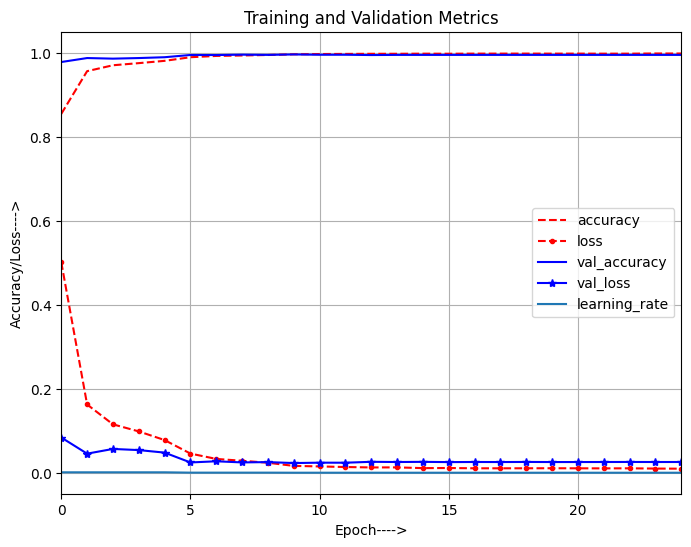

In [17]:
history_df = pd.DataFrame(history.history)
num_epochs = len(history_df)

history_df.plot(
    figsize=(8,6),
    xlim=[0, num_epochs - 1],
    ylim=[history_df.values.min() - 0.05, 1.05],
    grid=True,
    xlabel='Epoch---->',
    ylabel='Accuracy/Loss---->',
    style=['r--','r--.','b-','b-*'])
plt.title('Training and Validation Metrics')
plt.show()

### Model Evaluation
Calculate the final loss and accuracy on the unseen test dataset.

In [18]:
model.evaluate(X_test,y_test)

438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9950 - loss: 0.0250


[0.024957288056612015, 0.9950000047683716]

### Probability Predictions
Generate class probabilities for the test set using the trained model.

In [19]:
y_prob = model.predict(X_test)
y_prob

438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


array([[4.1603371e-06, 2.3583158e-05, 2.6859977e-06, ..., 2.6550616e-08,
        9.9990177e-01, 2.0659674e-05],
       [9.7578834e-08, 4.0468167e-06, 1.1209464e-06, ..., 2.3154817e-05,
        2.8757211e-06, 4.8695849e-05],
       [8.2625553e-07, 9.1055081e-06, 2.7288013e-06, ..., 1.1520482e-08,
        9.9994779e-01, 3.6585354e-06],
       ...,
       [1.2308548e-05, 1.9799852e-06, 9.9995637e-01, ..., 2.8988882e-06,
        1.5555072e-05, 9.9904732e-08],
       [1.2691129e-07, 3.0389303e-06, 2.2705667e-06, ..., 9.9997556e-01,
        6.3951717e-08, 5.6970716e-06],
       [5.1030702e-06, 9.9990630e-01, 3.4807285e-06, ..., 2.5297337e-05,
        8.3953382e-06, 1.5651647e-06]], dtype=float32)

### Final Class Predictions
Convert the predicted probabilities into class labels by selecting the index with the highest probability.

In [20]:
y_pred = y_prob.argmax(axis = -1)
y_pred

array([8, 4, 8, ..., 2, 7, 1])

### Standard Metrics
Calculate standard classification metrics including accuracy, precision, recall, F1-score.

In [21]:
accuracy = accuracy_score(y_test, y_pred)*100
precision = precision_score(y_test, y_pred, average='weighted')*100
recall = recall_score(y_test, y_pred, average='weighted')*100
f1 = f1_score(y_test, y_pred, average='weighted')*100

print(f'Accuracy: {accuracy:.6f}')
print(f'Precision (Weighted): {precision:.6f}')
print(f'Recall (Weighted): {recall:.6f}')
print(f'F1-Score (Weighted): {f1:.6f}')

Accuracy: 99.500000
Precision (Weighted): 99.500281
Recall (Weighted): 99.500000
F1-Score (Weighted): 99.499900


### Area Under the ROC Curve
Calculate the Area Under the Receiver Operating Characteristic Curve (ROC AUC) using a One-vs-Rest (OvR) strategy to evaluate the model's ability to distinguish between classes based on predicted probabilities.

In [22]:
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')*100
print(f'ROC AUC Score: {roc_auc:.6f}')

ROC AUC Score: 99.996544


### Advanced Classification Metrics
Calculate advanced metrics including Log Loss (to evaluate probability accuracy), Cohen's Kappa (to account for chance agreement), and Matthews Correlation Coefficient (for overall classification quality).

In [23]:
loss = log_loss(y_test, y_prob)
kappa = cohen_kappa_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print(f'Log Loss: {loss:.6f}')
print(f'Cohen Kappa Score: {kappa:.6f}')
print(f'Matthews Correlation Coefficient: {mcc:.6f}')

Log Loss: 0.024957
Cohen Kappa Score: 0.994442
Matthews Correlation Coefficient: 0.994442


### Top-K Accuracy
Compute the Top-K accuracy score, which measures how often the true label is among the top 3 highest probability predictions made by the model.

In [24]:
top_3_accuracy = top_k_accuracy_score(y_test,y_prob, k=3)*100
print(f'Top-3 Accuracy score : {top_3_accuracy:.6f}')

Top-3 Accuracy score : 99.950000


### Confusion Matrix Visualization
Generate and plot a confusion matrix to identify which digits are being confused by the model.

In [25]:
cm = confusion_matrix(y_test,y_pred)
display(cm)

array([[1338,    0,    0,    0,    0,    0,    3,    1,    1,    0],
       [   0, 1596,    0,    0,    1,    0,    0,    3,    0,    0],
       [   0,    3, 1376,    0,    0,    0,    0,    1,    0,    0],
       [   0,    0,    1, 1428,    0,    1,    0,    1,    1,    1],
       [   0,    0,    0,    0, 1291,    0,    0,    0,    0,    4],
       [   0,    0,    0,    4,    0, 1267,    0,    0,    2,    0],
       [   1,    0,    1,    0,    2,    0, 1392,    0,    0,    0],
       [   0,    3,    2,    0,    1,    0,    0, 1494,    1,    2],
       [   0,    0,    3,    2,    0,    3,    2,    0, 1342,    5],
       [   1,    0,    0,    1,    7,    1,    0,    4,    0, 1406]])

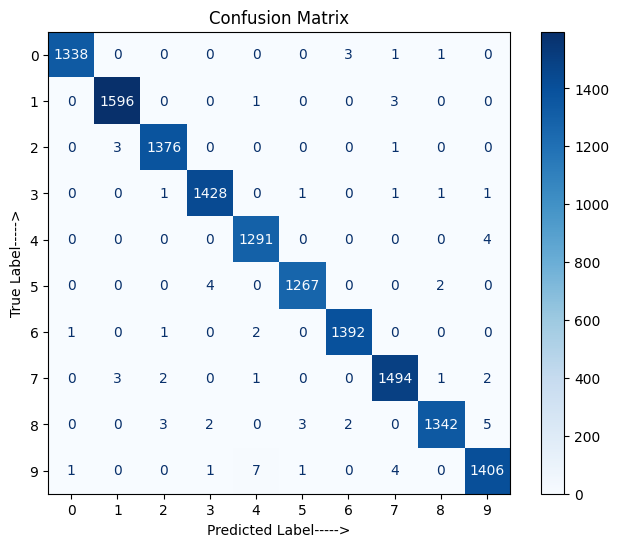

In [26]:
cm_display = ConfusionMatrixDisplay(cm)
fig, ax = plt.subplots(figsize=(8,6))
cm_display.plot(cmap='Blues', ax=ax, colorbar=True, values_format='d')
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted Label----->')
ax.set_ylabel('True Label----->')
plt.show()

### Per-Class Accuracy Analysis
Visualize the accuracy for each individual digit to identify specific weaknesses.

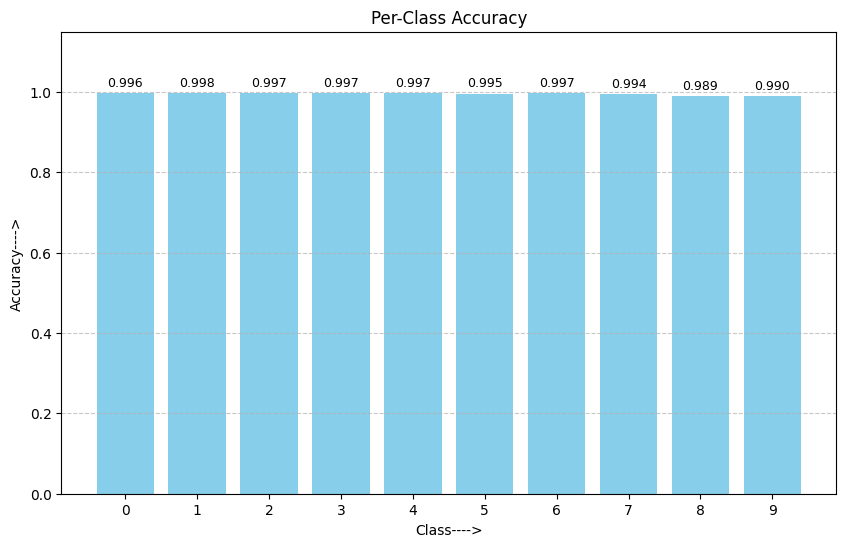

In [27]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(per_class_accuracy)), per_class_accuracy, tick_label=range(len(per_class_accuracy)), color='skyblue')

# Adding specific values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontsize=9)

plt.xlabel('Class---->')
plt.ylabel('Accuracy---->')
plt.title('Per-Class Accuracy')
plt.ylim(0, 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Precision-Recall and ROC Curves
Plot multiclass Precision-Recall and ROC curves to evaluate the trade-off between sensitivity and specificity.

In [28]:
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)
n_classes = y_test_binarized.shape[1]

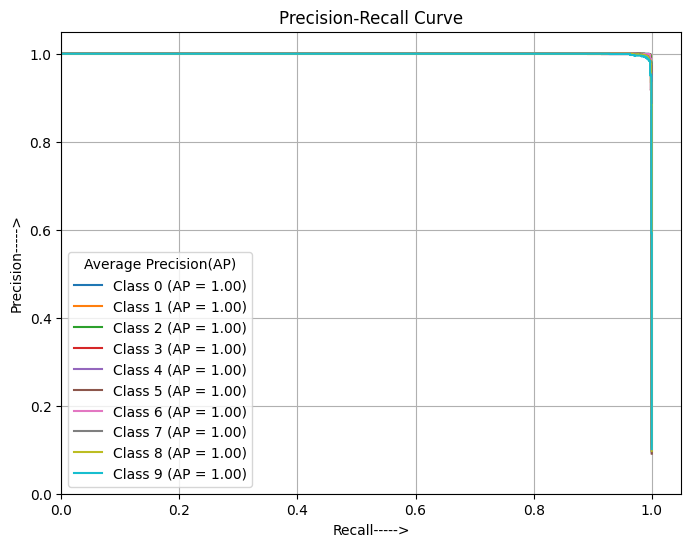

In [29]:
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_prob[:, i])
    average_precision = average_precision_score(y_test_binarized[:, i], y_prob[:, i])
    plt.plot(recall, precision, drawstyle = 'steps-post',label=f'Class {i} (AP = {average_precision:.2f})')

plt.xlabel('Recall----->')
plt.ylabel('Precision----->')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left',title = 'Average Precision(AP)')
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.grid(True)
plt.show()

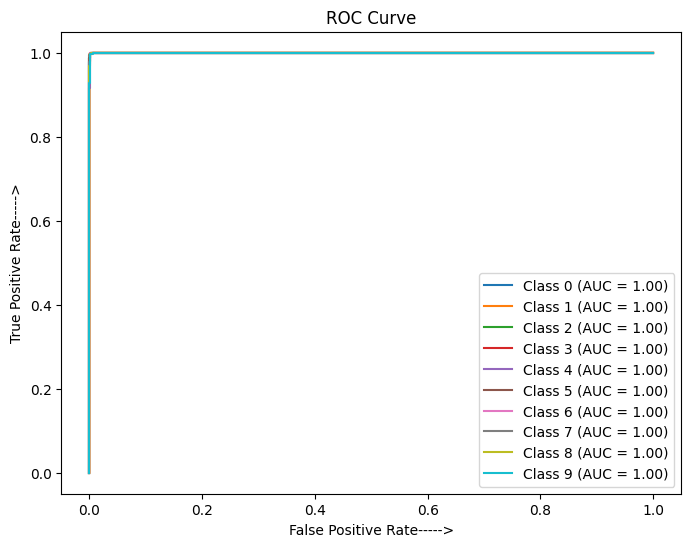

In [30]:
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc_val:.2f})')
plt.legend()
plt.title('ROC Curve')
plt.xlabel('False Positive Rate----->')
plt.ylabel('True Positive Rate----->')
plt.show()

### Prediction Confidence Histogram
Examine the distribution of the model's highest predicted probabilities to assess its confidence levels.

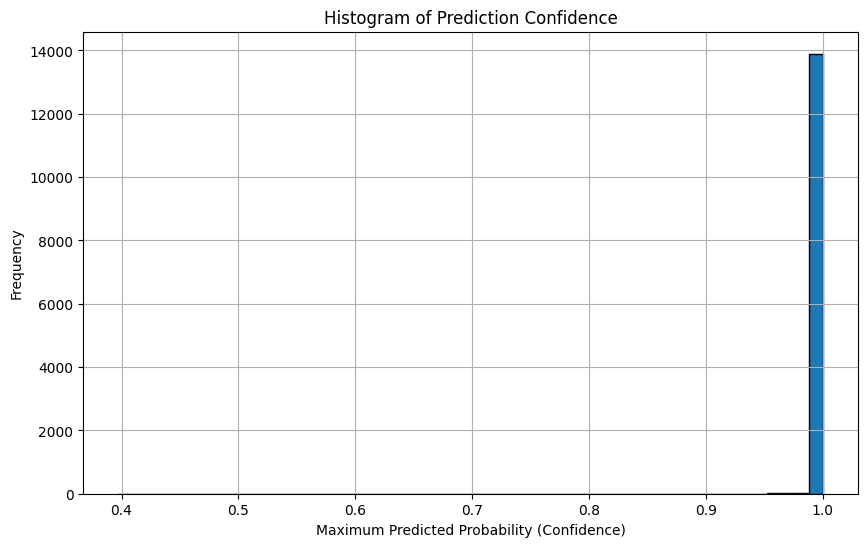

In [31]:
y_pred_proba_max = np.max(y_prob, axis=1)

plt.figure(figsize=(10, 6))
plt.hist(y_pred_proba_max, bins=50, edgecolor='black')
plt.xlabel('Maximum Predicted Probability (Confidence)')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Confidence')
plt.grid(True)
plt.show()

### Classification Report Heatmap
Visualize the classification report (precision, recall, f1-score) as a heatmap for easy interpretation.

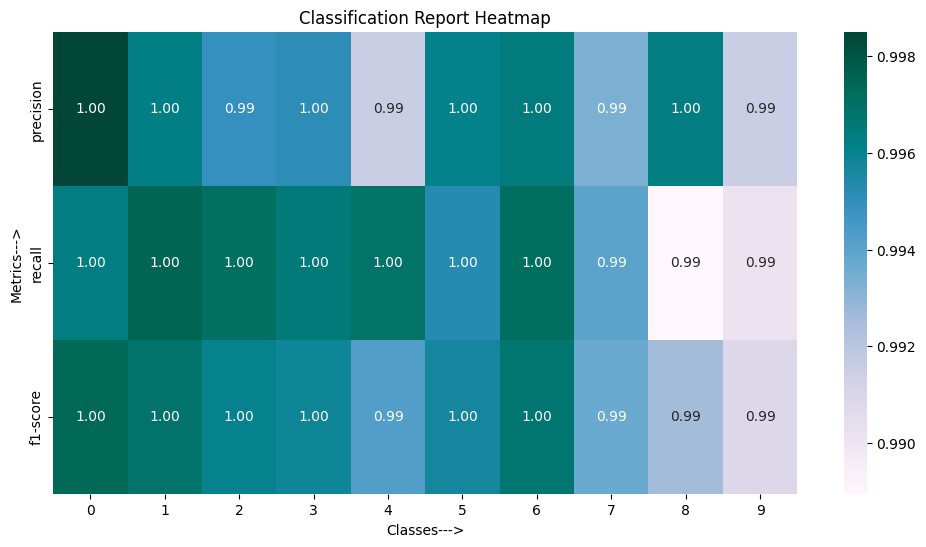

In [32]:
clf_report = classification_report(y_test, y_pred, output_dict=True)
clf_report_df = pd.DataFrame(clf_report).transpose().drop(columns=['support'])
plt.figure(figsize=(12, 6))
sns.heatmap(clf_report_df.iloc[:-3, :].T, annot=True, cmap='PuBuGn', fmt='.2f')
plt.title('Classification Report Heatmap')
plt.ylabel('Metrics--->')
plt.xlabel('Classes--->')
plt.show()

### Error Analysis
Identify and isolate indices where the predicted label does not match the true label.

In [33]:
misclassified_idx = np.where(y_test != y_pred)[0]

In [34]:
len(misclassified_idx)

70

### Visualization of Misclassified Images
Display the first 25 images that the model failed to classify correctly, showing both true and predicted labels.

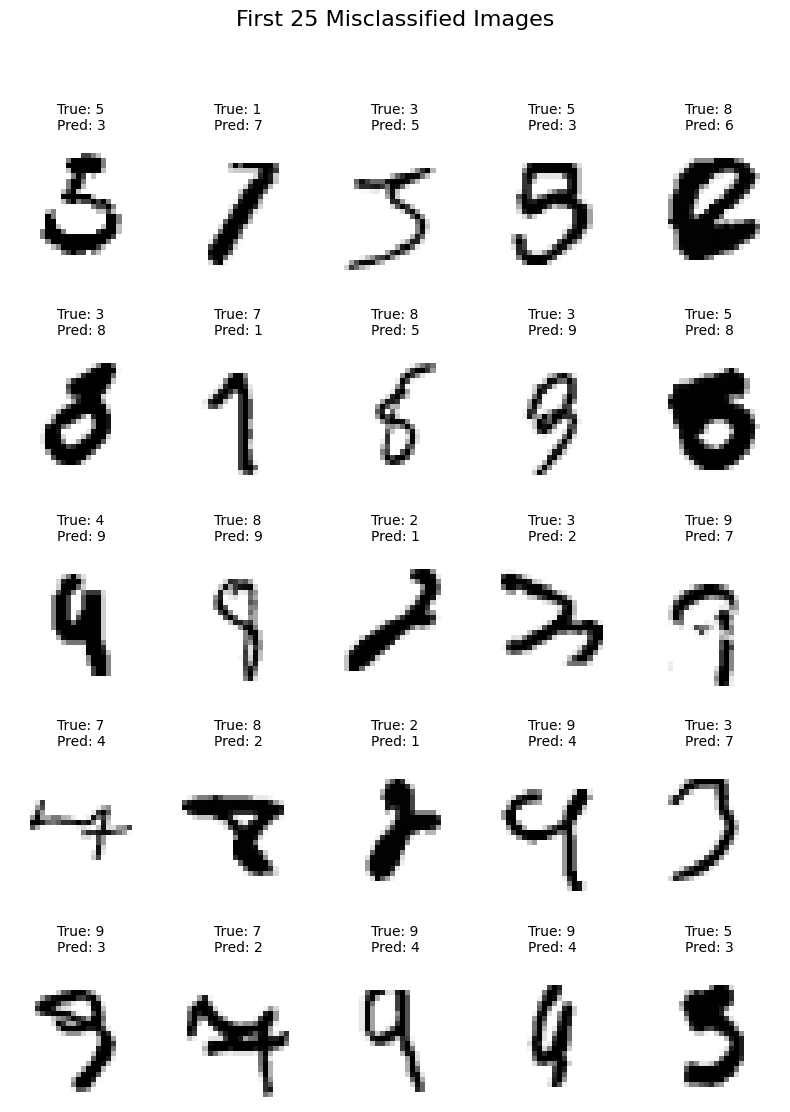

In [35]:
plt.figure(figsize=(8,12))
plt.suptitle('First 25 Misclassified Images', fontsize=16)
for i, idx in enumerate(misclassified_idx[:25]):
    plt.subplot(5, 5, i + 1)
    image_data = X_test[idx].reshape(28, 28)
    plt.imshow(image_data, cmap='binary')
    plt.title(f'True: {y_test[idx]}\nPred: {y_pred[idx]}', fontsize=10)
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Model Serialization
Save the trained model to a file using `joblib` for future deployment or inference.

In [36]:
import joblib
joblib.dump(model,'CNN_model_mnist.pkl')
print('CNN model dumped successfully.')

CNN model dumped successfully.
